# Experiences sur les résultats obtenues avec notre modèle d'ordonnancement

In [155]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from first_model import Instance, Solution, Model
from utils import read_file, plot_levels_workers, gantt_chart, plot_precedence_graph, plot_precedence_graph_sub_operations

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## I. Visualisation du graphe de précédence des opérations et sous-opérations pour chaque Job du fichier suivant: 
**data_many_constraints_precedence.test**

Ce fichier contient **2 jobs**, chacun avec **5 opérations**, une opération peut contenir au maximum **10 sous-opérations**

In [156]:
res_many_constraints = read_file("../data/data_many_constraints_precedence.test")
instance_many_constraints = Instance(res_many_constraints)

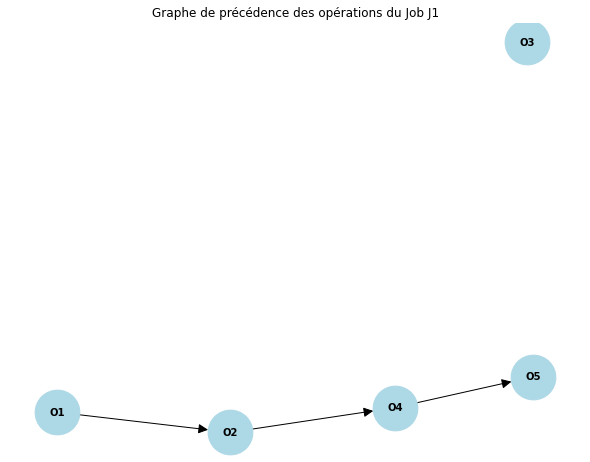

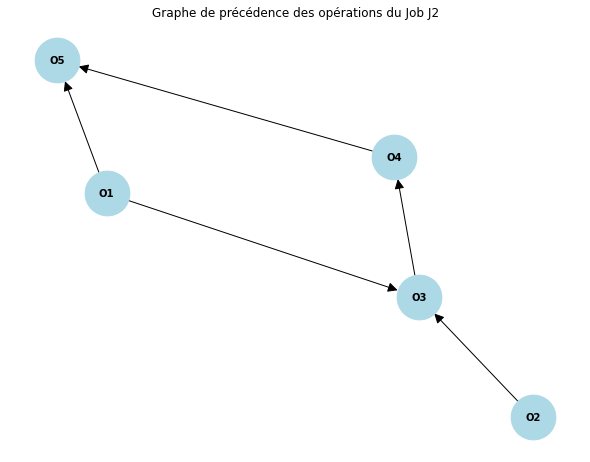

In [157]:
plot_precedence_graph(instance_many_constraints)

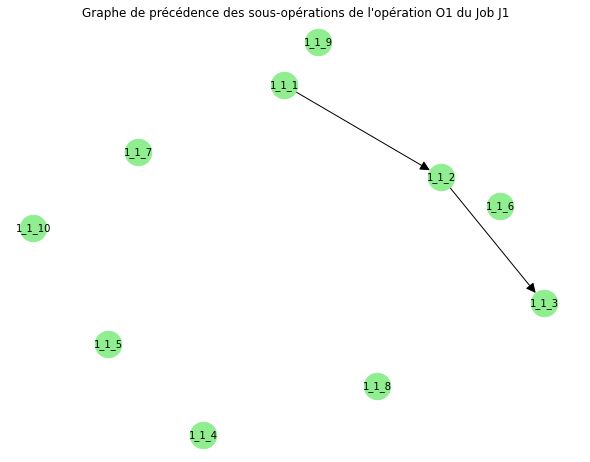

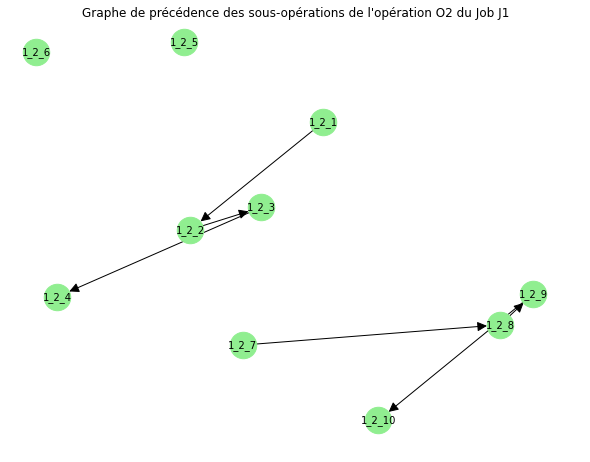

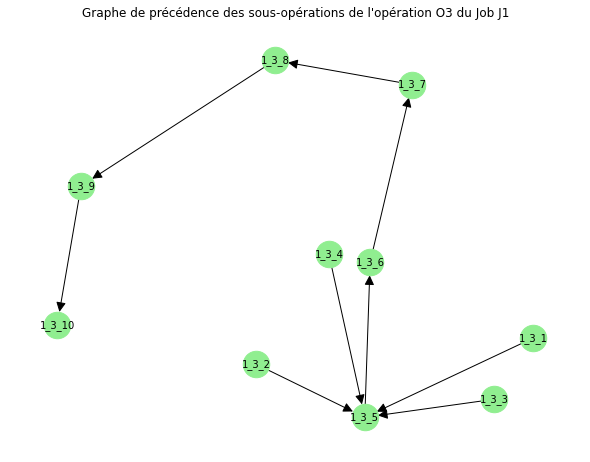

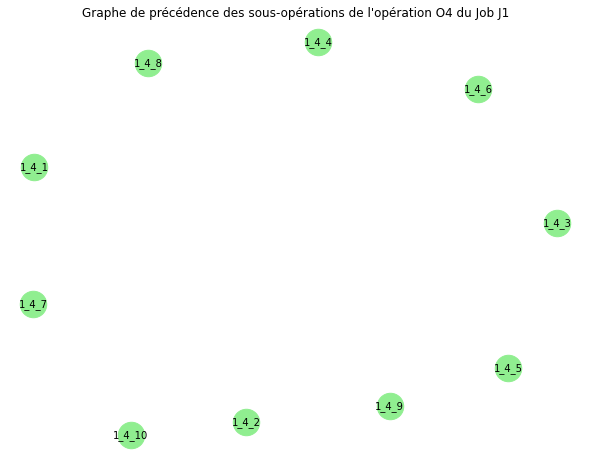

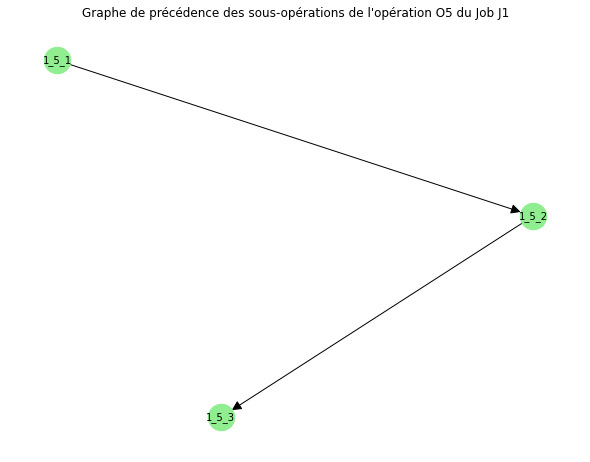

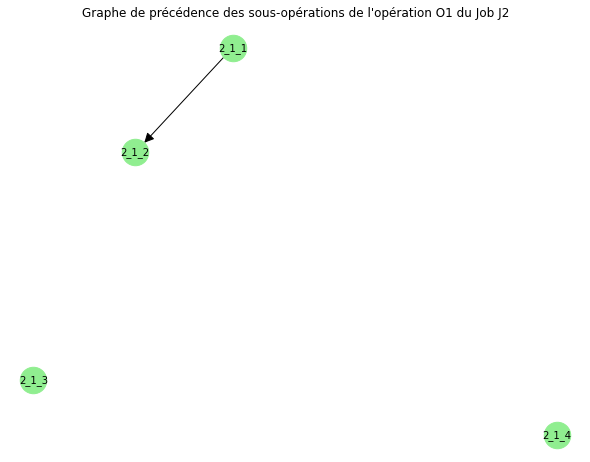

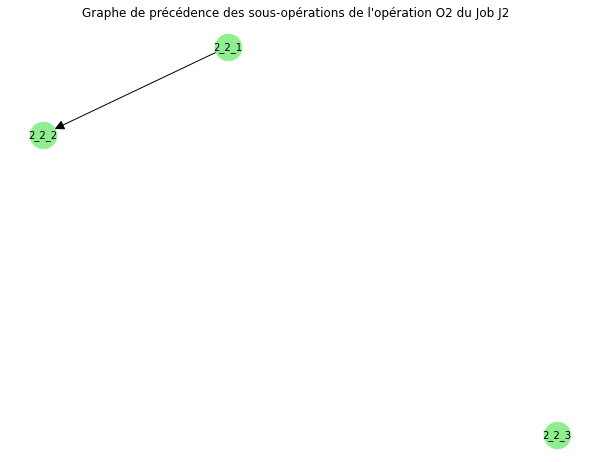

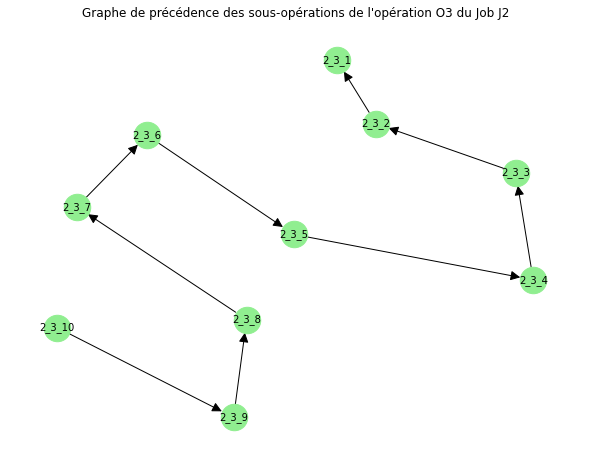

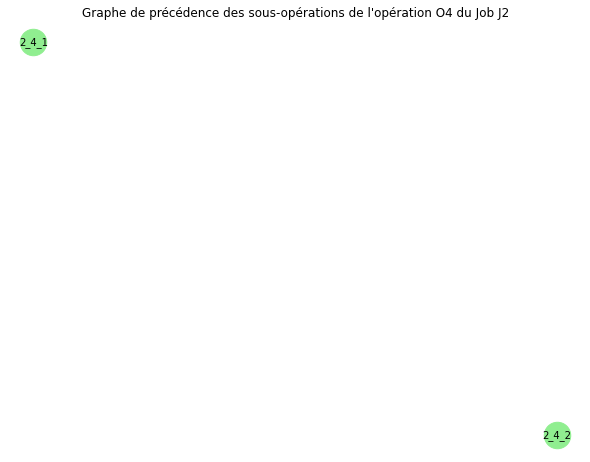

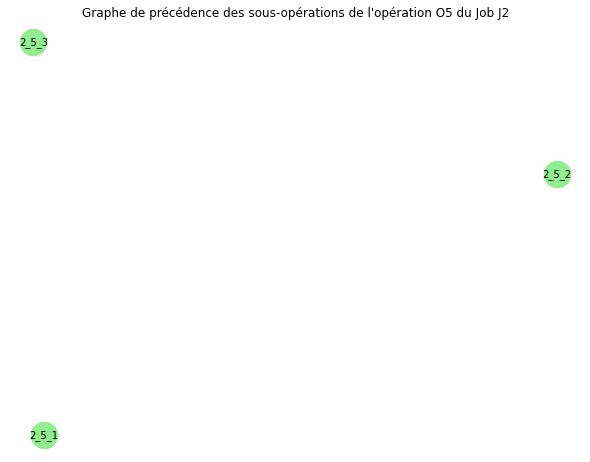

In [158]:
plot_precedence_graph_sub_operations(instance_many_constraints)

## II. Instance plus simple pour tester résultats

### 1) Visualisation des graphes de précédence

In [160]:
res = read_file("../data/data_temp.test")
instance = Instance(res)
print(instance)

-------------------------------------
Start of Instance:
-------------------------------------
Number of jobs: 2
Number of professions: 3
Number of sub-operations per profession: [2. 4. 1.]
Max number of operations per Jobs: 2
Max number of sub-operations per operation: 3
Total number of sub-operations: 7
Total number of workers: 3
Sub-operation to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2}
Worker levels: shape=(3, 3)
 [[1. 2. 1.]
 [4. 3. 2.]
 [1. 2. 1.]]
Job difficulties: shape= (2,)
[2. 2.]
Sub-operation difficulties: shape= (7,)
[1 1 3 3 2 2 2]
Sub-operation processing times: shape= (7, 3)
[[ 3.  4.  2.]
 [15. 15. -1.]
 [ 5.  8.  2.]
 [ 4.  6.  2.]
 [ 5. 10.  2.]
 [ 4. 11.  2.]
 [10. 20.  2.]]
Jobs structure: len= 2
Job 0 : 
	O_0 : 0 2 6 
	O_1 : 2 
Job 1 : 
	O_0 : 3 1 
	O_1 : 6 4 4 

Precedence constraints: shape= (2, 2, 2)
[[[0. 1.]
  [0. 0.]]

 [[0. 0.]
  [1. 0.]]]
Sub-operation precedence constraints: shape= (2, 2, 3, 3)
[[[[0. 1. 0.]
   [0. 0. 1.]
   [0. 0. 0

### 1a) Précédence entre les opérations d'un même job

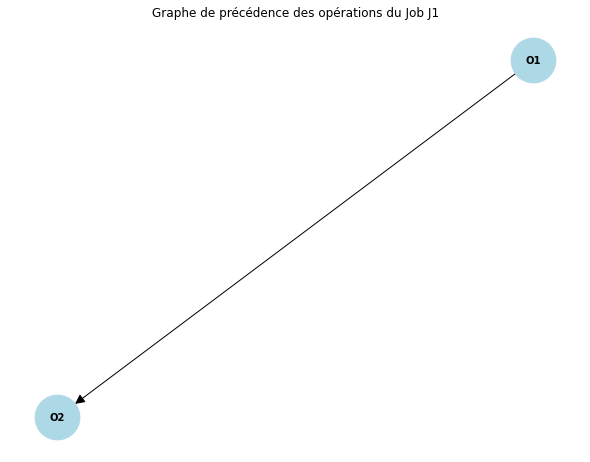

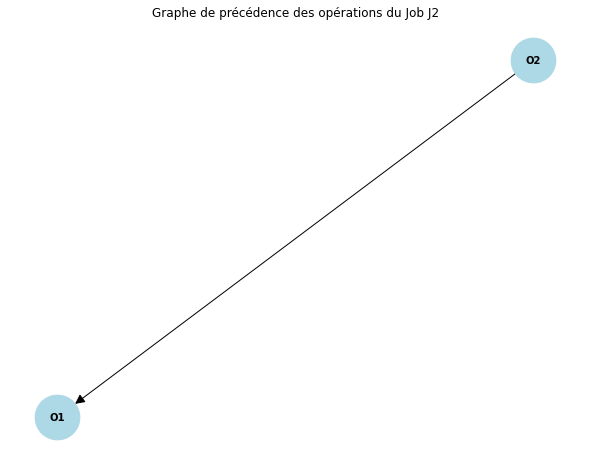

In [161]:
plot_precedence_graph(instance)

### 1b) Précédence entre les sous-opérations d'une même opération d'un job

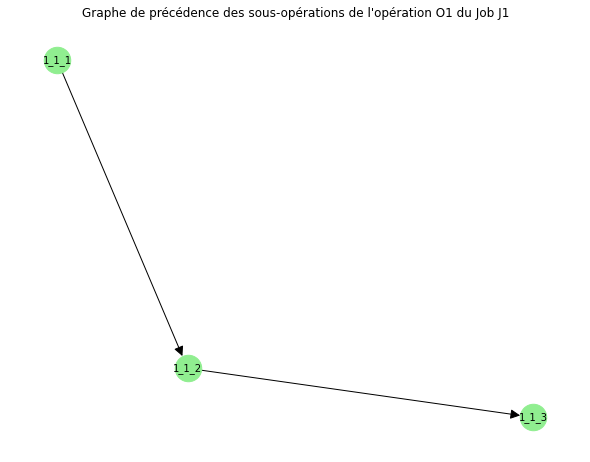

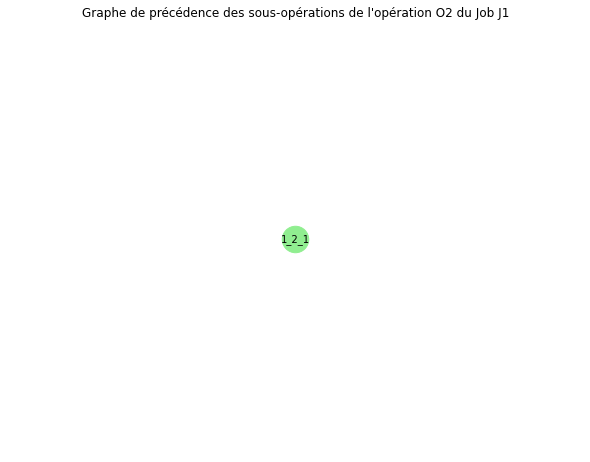

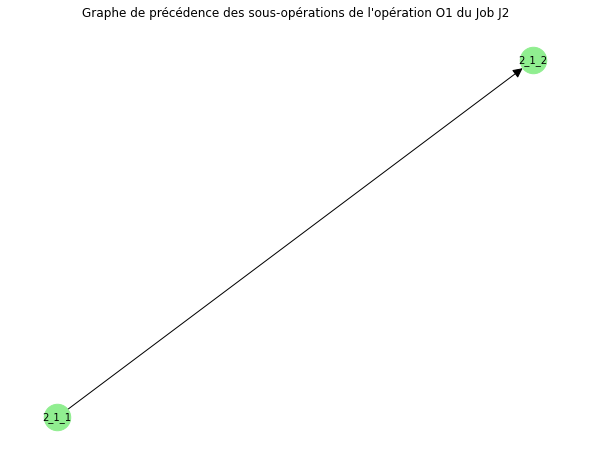

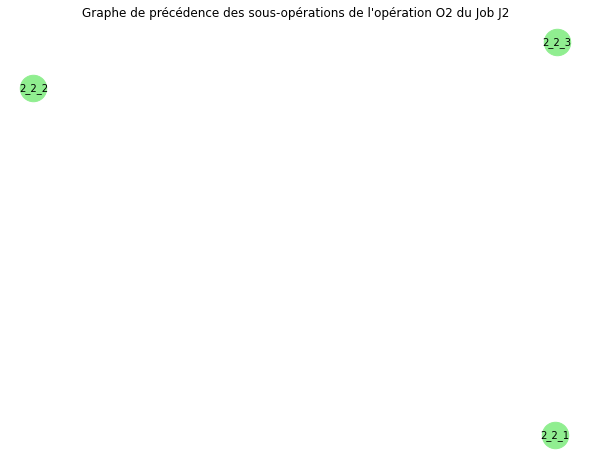

In [162]:
plot_precedence_graph_sub_operations(instance)

### 2) Résolution par la programmation linéaire avec Gurobi

# Min makespan seulement

In [176]:
model = Model(instance)
s = model.solve(objective="makespan",weight=[0.5, 0.5], priority=[0, 0], verbose=False)

Optimal solution found with objective value: 55.99999998831546


### 3) Visualisation du diagramme de Gantt

PS : Dans le data Frame de sortie de la fonction gantt_chart, j'ai ajouté + $0.1$ à chaque start pour pouvoir espacer les différentes tâches sur le diagramme de Gantt et éviter que les tâches soient collées les unes aux autres.

#### 3.1) Visualisation par sous-opération

In [181]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,3.1,5.0,"(2,2,3)","(2,2)",J2,collaboratively
1,w1,20.1,22.0,"(2,2,2)","(2,2)",J2,collaboratively
2,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone
3,w2,3.1,5.0,"(2,2,3)","(2,2)",J2,collaboratively
4,w2,5.1,10.0,"(1,1,2)","(1,1)",J1,alone
5,w2,10.1,20.0,"(2,2,1)","(2,2)",J2,alone
6,w2,20.1,22.0,"(2,2,2)","(2,2)",J2,collaboratively
7,w2,22.1,32.0,"(1,1,3)","(1,1)",J1,alone
8,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
9,w2,36.1,41.0,"(1,2,1)","(1,2)",J1,alone


#### 3.2) Visualisation par opération

In [182]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

#### 3.3) Visualisation par job

In [183]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

#### 3.4) Visualisationn par mode d'éxécution (seul, en apprentissage ou en collaboration)

In [184]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

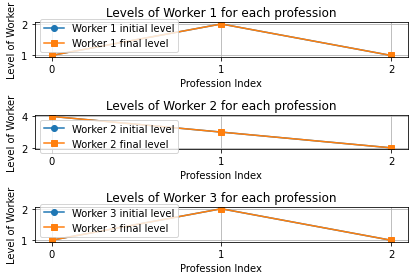

In [185]:
plot_levels_workers(s, instance)

# Max skill seulement

In [186]:
s = model.solve(objective="skill",weight=[0.5, 0.5], priority=[0, 0], verbose=False)

Optimal solution found with objective value: 19.0


In [187]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,3.1,11.0,"(1,1,2)","(1,1)",J1,learning
1,w1,31.1,33.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w1,33.1,35.0,"(2,2,2)","(2,2)",J2,collaboratively
3,w1,35.1,55.0,"(2,2,1)","(2,2)",J2,learning
4,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone
5,w2,3.1,11.0,"(1,1,2)","(1,1)",J1,learning
6,w2,11.1,31.0,"(1,1,3)","(1,1)",J1,learning
7,w2,31.1,33.0,"(2,2,3)","(2,2)",J2,collaboratively
8,w2,33.1,35.0,"(2,2,2)","(2,2)",J2,collaboratively
9,w2,35.1,55.0,"(2,2,1)","(2,2)",J2,learning


In [188]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [189]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [190]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

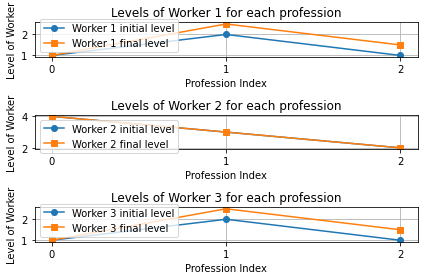

In [191]:
plot_levels_workers(s, instance)

# Min Makespan puis max skill (lexicographic)

In [192]:
s = model.solve(objective="lexicographic",weight=[0.5, 0.5], priority=[1, 0], verbose=False)

Optimal solution found with objective value: 56.00560025319356


In [193]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,10.1,12.0,"(2,2,2)","(2,2)",J2,collaboratively
1,w2,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w2,2.1,5.0,"(1,1,1)","(1,1)",J1,alone
3,w2,5.1,10.0,"(1,1,2)","(1,1)",J1,alone
4,w2,10.1,12.0,"(2,2,2)","(2,2)",J2,collaboratively
5,w2,12.1,22.0,"(2,2,1)","(2,2)",J2,alone
6,w2,22.1,32.0,"(1,1,3)","(1,1)",J1,alone
7,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
8,w2,36.1,51.0,"(2,1,2)","(2,1)",J2,alone
9,w2,51.1,56.0,"(1,2,1)","(1,2)",J1,alone


In [194]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [195]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [196]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

# Max skill, puis Min Makespan (lexicographic)

In [197]:
s = model.solve(objective="lexicographic",weight=[0.5, 0.5], priority=[0, 1], verbose=False)

Optimal solution found with objective value: 78.99999999199957


In [198]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,2.1,22.0,"(2,2,1)","(2,2)",J2,learning
1,w2,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w2,2.1,22.0,"(2,2,1)","(2,2)",J2,learning
3,w2,22.1,24.0,"(2,2,2)","(2,2)",J2,collaboratively
4,w2,24.1,32.0,"(1,1,2)","(1,1)",J1,learning
5,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
6,w2,36.1,56.0,"(1,1,3)","(1,1)",J1,learning
7,w2,56.1,64.0,"(1,2,1)","(1,2)",J1,learning
8,w2,64.1,79.0,"(2,1,2)","(2,1)",J2,alone
9,w3,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively


In [199]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [200]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [201]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")